/tmp/ipykernel_588/4070776231.py:173: UserWarning: Glyph 129438 (\N{LOBSTER}) missing from font(s) DejaVu Sans.
  ani.save(gif_path, writer=writer, dpi=100)
/tmp/ipykernel_588/4070776231.py:173: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  ani.save(gif_path, writer=writer, dpi=100)


GIF guardado en: /mnt/user-data/outputs/lobster_morph.gif


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


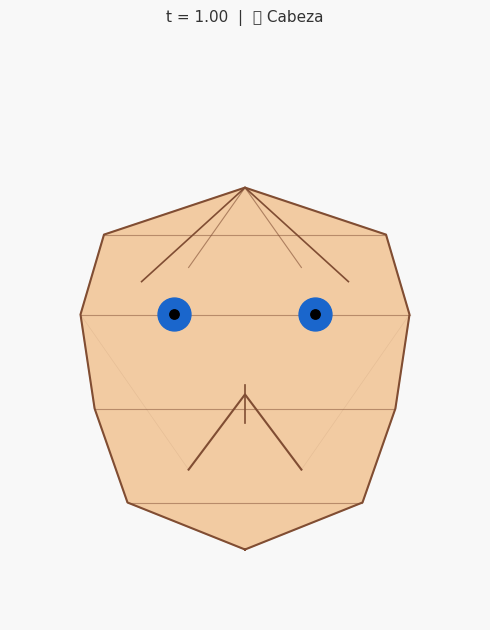

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import FancyArrowPatch
from scipy.interpolate import CubicSpline
import os


LOBSTER_POINTS = np.array([
    # cuerpo principal (elipse alargada)
    [0.5, 0.3],   # 0 base cola
    [0.2, 0.4],   # 1 izq cola
    [0.8, 0.4],   # 2 der cola
    [0.15, 0.55], # 3 izq medio
    [0.85, 0.55], # 4 der medio
    [0.2, 0.7],   # 5 izq torax
    [0.8, 0.7],   # 6 der torax
    [0.3, 0.85],  # 7 izq cabeza langosta
    [0.7, 0.85],  # 8 der cabeza langosta
    [0.5, 0.95],  # 9 punta cabeza / rostro
    # antenas
    [0.25, 1.05], # 10 antena izq larga
    [0.75, 1.05], # 11 antena der larga
    [0.35, 1.1],  # 12 antena izq corta
    [0.65, 1.1],  # 13 antena der corta
    # ojos (langosta)
    [0.38, 0.92], # 14 ojo izq
    [0.62, 0.92], # 15 ojo der
    # pinzas
    [0.05, 0.65], # 16 punta pinza izq
    [0.95, 0.65], # 17 punta pinza der
    # centro cuerpo
    [0.5, 0.6],   # 18 centro
    [0.5, 0.5],   # 19 cintura
])

HEAD_POINTS = np.array([
    # contorno cabeza (oval)
    [0.5, 0.15],  # 0 mentón
    [0.25, 0.25], # 1 izq mandíbula
    [0.75, 0.25], # 2 der mandíbula
    [0.18, 0.45], # 3 izq mejilla
    [0.82, 0.45], # 4 der mejilla
    [0.15, 0.65], # 5 izq sien
    [0.85, 0.65], # 6 der sien
    [0.2, 0.82],  # 7 izq frente
    [0.8, 0.82],  # 8 der frente
    [0.5, 0.92],  # 9 corona
    # cejas
    [0.28, 0.72], # 10 ceja izq ext
    [0.72, 0.72], # 11 ceja der ext
    [0.38, 0.75], # 12 ceja izq int
    [0.62, 0.75], # 13 ceja der int
    # ojos (humano)
    [0.35, 0.65], # 14 ojo izq centro
    [0.65, 0.65], # 15 ojo der centro
    # boca extremos
    [0.38, 0.32], # 16 comisura izq
    [0.62, 0.32], # 17 comisura der
    # nariz
    [0.5, 0.5],   # 18 punta nariz
    [0.5, 0.42],  # 19 base nariz
])




assert len(LOBSTER_POINTS) == len(HEAD_POINTS), "Mismo numero de puntos"

def compute_morph_path(src, dst, n_frames=60):
  t_key = np.array([0.0,0.33,0.66, 1.0])
  frames = np.linspace(0,1,n_frames)
  n_pts = src.shape[0]
  path = np.zeros((n_frames, n_pts, 2))

  for i in range(n_pts):
    for dim in range(2):
        mid1 = src[i, dim] * 0.6 + dst[i, dim] * 0.4
        mid2 = src[i, dim] * 0.3 + dst[i, dim] * 0.7
        y_key = np.array([src[i, dim], mid1, mid2, dst[i, dim]])
        cs = CubicSpline(t_key, y_key)
        path[:, i, dim] = cs(frames)

  return path


N_FRAMES = 80
morph_path = compute_morph_path(LOBSTER_POINTS, HEAD_POINTS, N_FRAMES)

def draw_shape(ax, pts, t):
    ax.clear()
    ax.set_xlim(0,1)
    ax.set_ylim(0, 1.25)
    ax.set_aspect('equal')
    ax.axis('off')

    color_body = (1-t) * np.array([0.85, 0.2, 0.1]) + t * np.array([0.95, 0.78, 0.6])
    color_eye  = (1-t) * np.array([0.1,0.1,0.1]) + t * np.array([0.1,0.4,0.8])
    color_line = (1-t) * np.array([0.7,0.1,0.05]) + t * np.array([0.5,0.3,0.2])


    body_idx = [0,1,3,5,7,9,8,6,4,2,0]
    body_pts = pts[body_idx]
    ax.fill(body_pts[:,0], body_pts[:,1], color = color_body, zorder=1, alpha=0.9)
    ax.plot(body_pts[:,0], body_pts[:,1], color=color_line, lw=1.5, zorder=2)

    for left, right in [(1,2), (3,4), (5,6), (7,8)]:
        ax.plot([pts[left,0], pts[right,0]],
                [pts[left,1], pts[right,1]],
                color=color_line, lw=0.8, alpha=0.5, zorder=3)

    # Antennas
    ax.plot([pts[9,0], pts[10,0]], [pts[9,1], pts[10,1]],
            color=color_line, lw=1.2 + (1-t)*1.5, zorder=3)
    ax.plot([pts[9,0], pts[11,0]], [pts[9,1], pts[11,1]],
            color=color_line, lw=1.2 + (1-t)*1.5, zorder=3)
    ax.plot([pts[9,0], pts[12,0]], [pts[9,1], pts[12,1]],
            color=color_line, lw=0.8, alpha=0.6, zorder=3)
    ax.plot([pts[9,0], pts[13,0]], [pts[9,1], pts[13,1]],
            color=color_line, lw=0.8, alpha=0.6, zorder=3)

    for eye in [14,15]:
        circle = plt.Circle(pts[eye], 0.025 + t*0.01, color=color_eye, zorder = 4)
        ax.add_patch(circle)
        pupil = plt.Circle(pts[eye], 0.010, color='black', zorder=5)
        ax.add_patch(pupil)

    ax.plot([pts[5,0], pts[16,0]], [pts[5,1], pts[16,1]],
            color=color_line, lw=1.5*(1-t)+0.5, alpha=max(0.1, 1-t*1.2), zorder = 3)
    ax.plot([pts[6,0], pts[17,0]], [pts[6,1], pts[17,1]],
            color=color_line, lw=1.5*(1-t) + 0.5, alpha=max(0.1,1-t*1.2), zorder=3)

    if t > 0.4:
      alpha_mouth = (t - 0.4) / 0.6
      ax.plot([pts[16,0], pts[18,0], pts[17,0]],
              [pts[16,1], pts[18,1]-0.02, pts[17,1]],
              color=color_line, lw=1.5, alpha=alpha_mouth, zorder=4)

    if t > 0.5:
      alpha_nose = (t - 0.5) / 0.5
      ax.plot([pts[18,0], pts[19,0]], [pts[18,1], pts[19,1]],
              color = color_line, lw=1.2, alpha=alpha_nose, zorder=4)

    label = f"t = {t:.2f}  |  {'🦞 Langosta' if t < 0.5 else '👤 Cabeza'}"
    ax.set_title(label, fontsize=11, pad=8, color='#333333')
    ax.set_facecolor('#f8f8f8')



fig, ax = plt.subplots(figsize=(5,6.5))
fig.patch.set_facecolor('#f8f8f8')

t_values = np.linspace(0,1,N_FRAMES)

def update(frame):
    draw_shape(ax, morph_path[frame], t_values[frame]) # Changed t_values[frames] to t_values[frame]
    return ax,

ani = animation.FuncAnimation(
    fig, update,
    frames=N_FRAMES,
    interval=50,
    blit=False,
    repeat=True
)

# Create the directory if it doesn't exist
output_dir = os.path.dirname('/mnt/user-data/outputs/lobster_morph.gif')
os.makedirs(output_dir, exist_ok=True)

gif_path = '/mnt/user-data/outputs/lobster_morph.gif'
writer = animation.PillowWriter(fps=20)
ani.save(gif_path, writer=writer, dpi=100)
print(f"GIF guardado en: {gif_path}")

plt.tight_layout()
plt.show()